In [ ]:
import pandas as pd
df = pd.read_csv('/content/netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
# Convert date_added to actual datetime format
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')

# Extract just the year into a new column
df['year_added'] = df['date_added'].dt.year

# Check it worked
df[['title', 'date_added', 'year_added']].head()

,title,date_added,year_added
0,Dick Johnson Is Dead,2021-09-25,2021.0
1,Blood & Water,2021-09-24,2021.0
2,Ganglands,2021-09-24,2021.0
3,Jailbirds New Orleans,2021-09-24,2021.0
4,Kota Factory,2021-09-24,2021.0


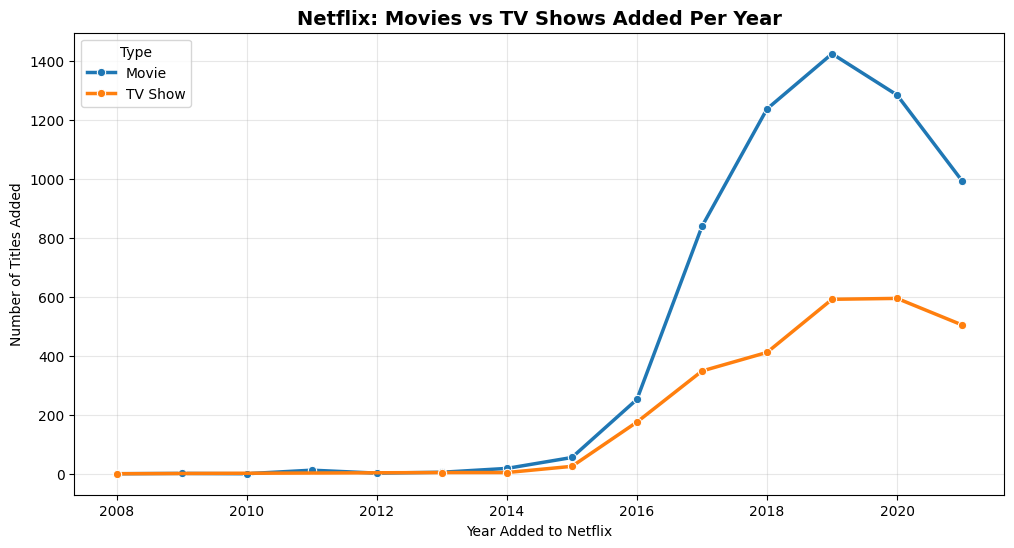

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count how many movies vs shows were added each year
yearly_counts = df.groupby(['year_added', 'type']).size().reset_index(name='count')

# Drop any rows where year is missing
yearly_counts = yearly_counts.dropna(subset=['year_added'])

# Plot it
plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_counts, x='year_added', y='count', hue='type', marker='o', linewidth=2.5)
plt.title('Netflix: Movies vs TV Shows Added Per Year', fontsize=14, fontweight='bold')
plt.xlabel('Year Added to Netflix')
plt.ylabel('Number of Titles Added')
plt.legend(title='Type')
plt.grid(alpha=0.3)
plt.show()

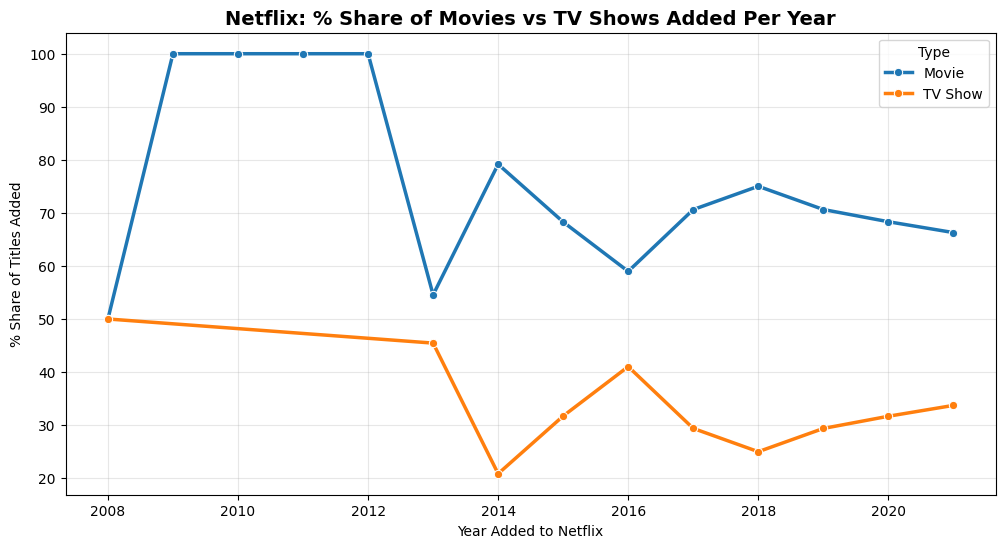

In [ ]:
# Get total titles added per year
yearly_totals = yearly_counts.groupby('year_added')['count'].transform('sum')

# Calculate % share
yearly_counts['percentage'] = (yearly_counts['count'] / yearly_totals) * 100

# Plot percentage instead of raw count
plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_counts, x='year_added', y='percentage', hue='type', marker='o', linewidth=2.5)
plt.title('Netflix: % Share of Movies vs TV Shows Added Per Year', fontsize=14, fontweight='bold')
plt.xlabel('Year Added to Netflix')
plt.ylabel('% Share of Titles Added')
plt.legend(title='Type')
plt.grid(alpha=0.3)
plt.show()

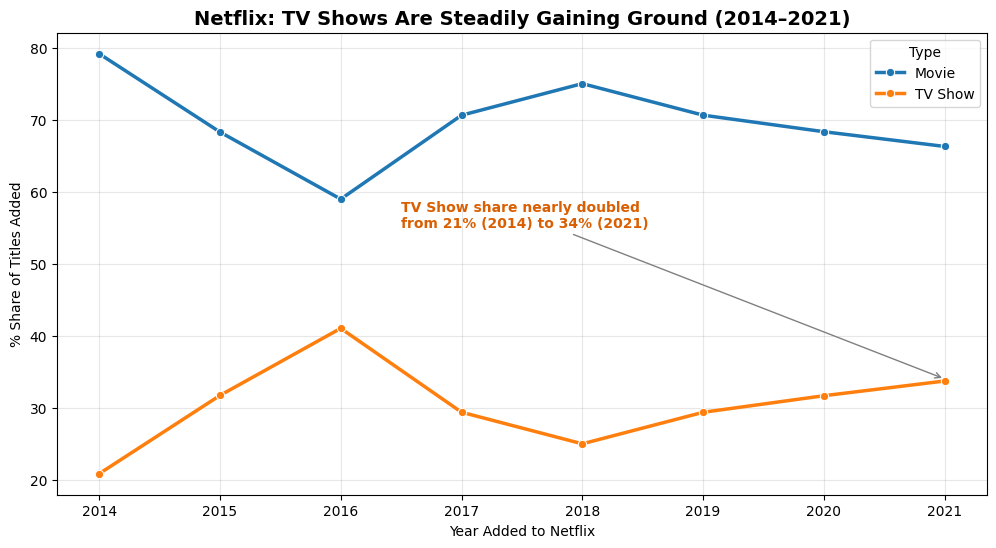

In [ ]:
# Filter to 2014 onward for a cleaner, more reliable story
recent = yearly_counts[yearly_counts['year_added'] >= 2014]

plt.figure(figsize=(12, 6))
sns.lineplot(data=recent, x='year_added', y='percentage', hue='type', marker='o', linewidth=2.5)
plt.title('Netflix: TV Shows Are Steadily Gaining Ground (2014–2021)', fontsize=14, fontweight='bold')
plt.xlabel('Year Added to Netflix')
plt.ylabel('% Share of Titles Added')
plt.legend(title='Type')
plt.grid(alpha=0.3)

# Annotate the key insight directly on the chart
plt.annotate('TV Show share nearly doubled\nfrom 21% (2014) to 34% (2021)',
             xy=(2021, 34), xytext=(2016.5, 55),
             arrowprops=dict(arrowstyle='->', color='gray'),
             fontsize=10, fontweight='bold', color='#d95f02')

plt.show()

In [ ]:
# Filter to only TV Shows
shows = df[df['type'] == 'TV Show'].copy()

# Extract the number from strings like "2 Seasons" -> 2
shows['num_seasons'] = shows['duration'].str.extract(r'(\d+)').astype(float)

# Check it worked
shows[['title', 'duration', 'num_seasons']].head()

,title,duration,num_seasons
1,Blood & Water,2 Seasons,2.0
2,Ganglands,1 Season,1.0
3,Jailbirds New Orleans,1 Season,1.0
4,Kota Factory,2 Seasons,2.0
5,Midnight Mass,1 Season,1.0


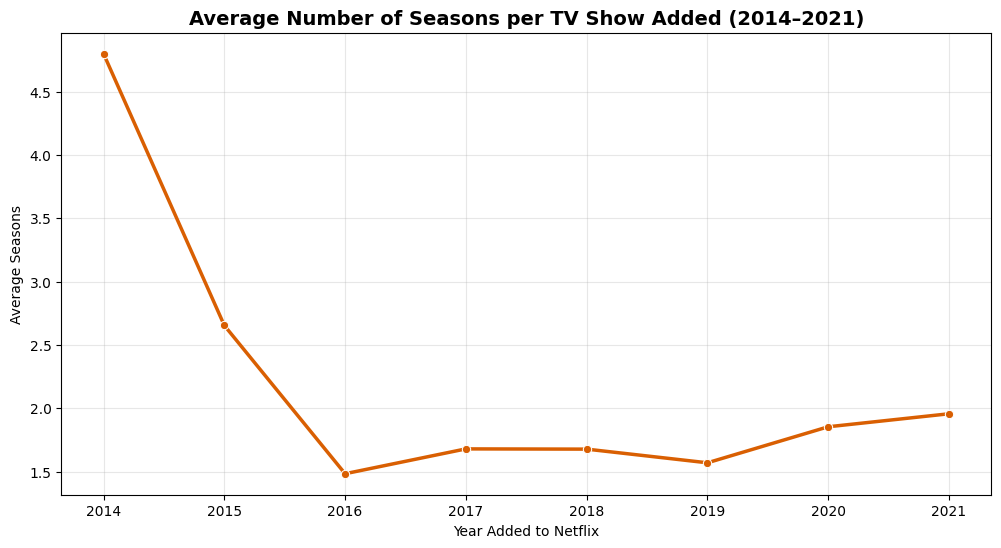

In [ ]:
# Average number of seasons per year (only for years with meaningful data)
seasons_trend = shows[shows['year_added'] >= 2014].groupby('year_added')['num_seasons'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=seasons_trend, x='year_added', y='num_seasons', marker='o', linewidth=2.5, color='#d95f02')
plt.title('Average Number of Seasons per TV Show Added (2014–2021)', fontsize=14, fontweight='bold')
plt.xlabel('Year Added to Netflix')
plt.ylabel('Average Seasons')
plt.grid(alpha=0.3)
plt.show()

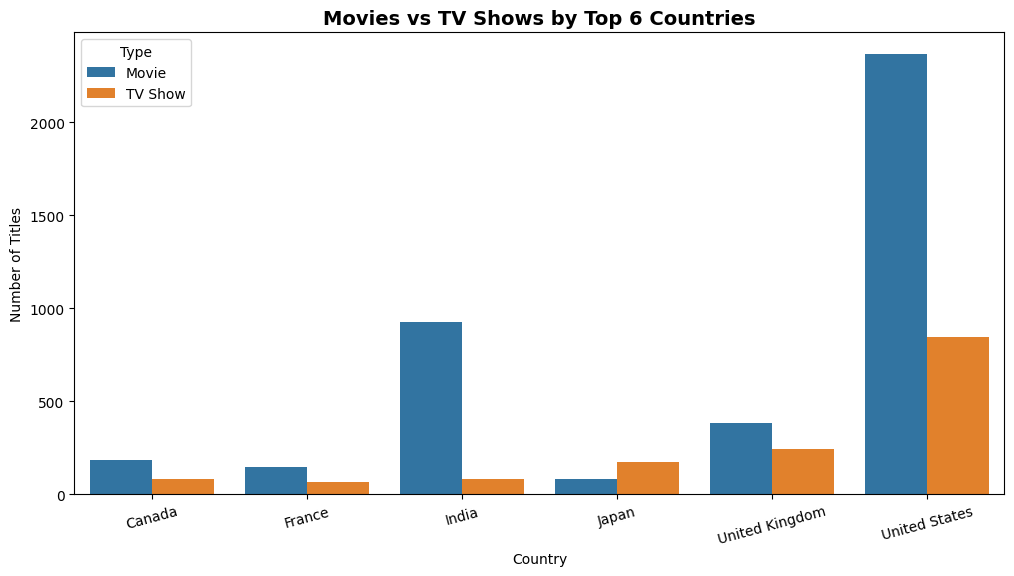

In [ ]:
# Country column can have multiple countries per row (comma-separated) - let's take just the first listed country for simplicity
df['main_country'] = df['country'].str.split(',').str[0]

# Get top 6 countries by total titles
top_countries = df['main_country'].value_counts().head(6).index

# Filter to just those countries
country_data = df[df['main_country'].isin(top_countries)]

# Count movie vs show split per country
country_split = country_data.groupby(['main_country', 'type']).size().reset_index(name='count')

plt.figure(figsize=(12, 6))
sns.barplot(data=country_split, x='main_country', y='count', hue='type')
plt.title('Movies vs TV Shows by Top 6 Countries', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.legend(title='Type')
plt.xticks(rotation=15)
plt.show()

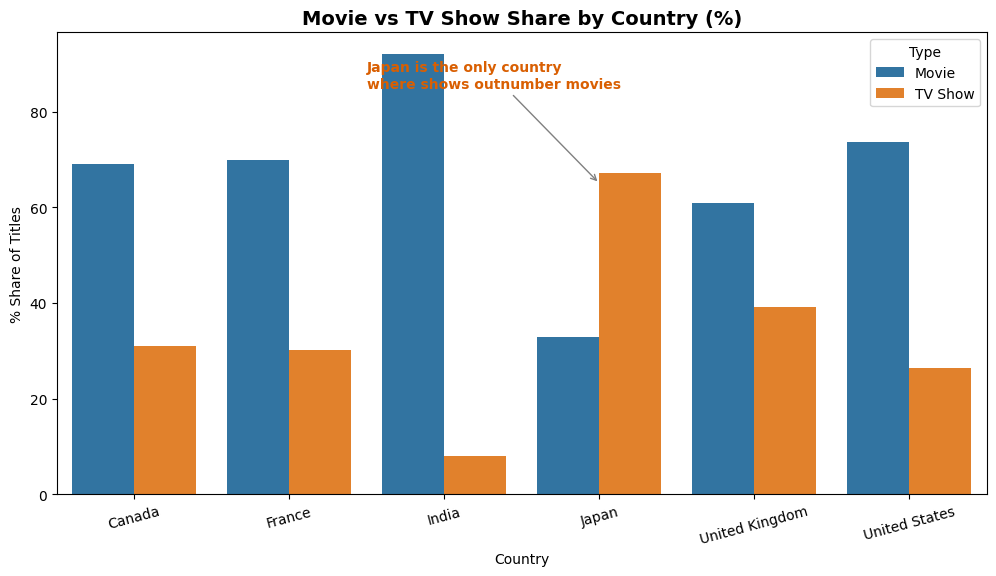

In [ ]:
# Get total titles per country
country_totals = country_split.groupby('main_country')['count'].transform('sum')

# Calculate % share within each country
country_split['percentage'] = (country_split['count'] / country_totals) * 100

plt.figure(figsize=(12, 6))
sns.barplot(data=country_split, x='main_country', y='percentage', hue='type')
plt.title('Movie vs TV Show Share by Country (%)', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('% Share of Titles')
plt.legend(title='Type')
plt.xticks(rotation=15)

# Annotate Japan since it's the standout
plt.annotate('Japan is the only country\nwhere shows outnumber movies',
             xy=(3, 65), xytext=(1.5, 85),
             arrowprops=dict(arrowstyle='->', color='gray'),
             fontsize=10, fontweight='bold', color='#d95f02')

plt.show()